In [24]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6_5min.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6_5min.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
#Restricts the timesteps of the data from timesteps0 to 140
res='1km';t_res='5min';Np_str='1e6'
job_array=False;index_adjust=0
ocean_fraction=0.25

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [10]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

Top 10 objects with highest memory usage
{'initiate_array_2D': '0.0 MB', 'initiate_array_4D': '0.0 MB', 'Ddt': '0.0 MB', 'Ddz': '0.0 MB', 'Ddz_4DStretch': '0.0 MB', 'Ddy_4D': '0.0 MB', 'Ddx_4d': '0.0 MB', 'Ddz_3D': '0.0 MB', 'Ddy_3D': '0.0 MB', 'Ddx_3D': '0.0 MB'}

0.0 GB in use overall


In [11]:
def check_memory():
    import sys
    ipython_vars = ["In", "Out", "exit", "quit", "get_ipython", "ipython_vars"]
    print("Top 10 objects with highest memory usage")
    # Get a sorted list of the objects and their sizes
    mem = {
        key: round(value/1e6,2)
        for key, value in sorted(
            [
                (x, sys.getsizeof(globals().get(x)))
                for x in globals()
                if not x.startswith("_") and x not in sys.modules and x not in ipython_vars
            ],
            key=lambda x: x[1],
            reverse=True)[:10]
    }
    print({key:f"{value} MB" for key,value in mem.items()})
    print(f"\n{round(sum(mem.values()),2)/1000} GB in use overall")

In [12]:
# Reading Back Data Later
##############
def make_data_dict(var_names,read_type):
    if read_type=='h5py':
        with h5py.File(in_file, 'r') as f:
            data_dict = {var_name: f[var_name][:] for var_name in var_names}
            
    elif read_type=='xarray':
        in_data = xr.open_dataset(
            in_file,
            engine='h5netcdf',
            phony_dims='sort',
            chunks={'phony_dim_0': 100, 'phony_dim_1': 1_000_000} 
        )
        data_dict = {k: in_data[k][:].compute().data for k in var_names}
    return data_dict

# read_type='xarray'
read_type='h5py'

In [25]:
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'

var_names = ['A_g', 'A_c', 'W', 'QCQI', 'Z', 'Y', 'X']
data_dict = make_data_dict(var_names,read_type)
A_g, A_c, W, QCQI, Z, Y, X = (data_dict[k] for k in var_names)

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)
check_memory()

Top 10 objects with highest memory usage
{'A_g': '1064.0 MB', 'A_c': '1064.0 MB', 'Z': '1064.0 MB', 'Y': '1064.0 MB', 'X': '1064.0 MB', 'W': '532.0 MB', 'QCQI': '532.0 MB', 'out': '24.0 MB', 'save': '24.0 MB', 'out_arr': '0.36 MB'}

6.43236 GB in use overall


In [28]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'VARS_binary_array_{res}_{t_res}_{Np_str}.h5'

var_names = ['QV','TH','TH_E','BUOYANCY','HMC']
data_dict = make_data_dict(var_names,read_type)
QV, TH, TH_E, BUOYANCY, HMC = (data_dict[k] for k in var_names)
check_memory()

Top 10 objects with highest memory usage
{'A_g': '1064.0 MB', 'A_c': '1064.0 MB', 'Z': '1064.0 MB', 'Y': '1064.0 MB', 'X': '1064.0 MB', 'W': '532.0 MB', 'QCQI': '532.0 MB', 'QV': '532.0 MB', 'TH': '532.0 MB', 'TH_E': '532.0 MB'}

7.98 GB in use overall


In [ ]:
################################################################################

In [44]:
# binary_array_path=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5' #DONT USE WITH LOOP INDEXING
# with h5py.File(binary_array_path, 'r') as f:
#     # Load the dataset by its name
#     X = f['X'][:]

# Reading Back Data Later
##################################################################
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
binary_array_path=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
def read_ZYX(t,p):
    with h5py.File(binary_array_path, 'r') as f:
        # Load the dataset by its name
        Z_tp = f['Z'][t,p]
        Y_tp = f['Y'][t,p]
        X_tp = f['X'][t,p]
    return Z_tp,Y_tp,X_tp

#DOMAIN SUBSETTING
def DOMAIN_SUBSET(out_arr):
    print(f'length before: {len(out_arr)}')

    ocean_percent=2/8
    left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
    
    where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
    where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
    end_xh=len(data['xh'])-1-50
    end_xf=len(data['xf'])-1-50
    
    print(f'x in {0}:{where_coast_xh-1} FOR SEA')
    print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
    # t_end=78 
    # if res=='250m':t_end=410
    # print(f't in {0}:{t_end} (6.5 hours)')
    t_start=36 
    t_end=len(data['time'])
    print(f't in {t_start}:end (8 hours)')

    #SUBSETTING CODE
    row,col=list(out_arr[:,1]),list(out_arr[:,0])
    
    # xs=X[row,col] #FANCY INDEXING
    
    #LOOP INDEXING (slightly longer, but avoids loading X into memory)
    ################
    with h5py.File(binary_array_path, 'r') as f:
        xs=[]
        for i, j in zip(row, col):
            xs.append(f['X'][i, j])
        xs=np.array(xs)
    ################
    
    out_arr=out_arr[np.where((xs>=where_coast_xh)&(xs<=end_xh))]
    out_arr=out_arr[np.where(out_arr[:,1]<=t_end)]

    print(f'length after: {len(out_arr)}')
    return out_arr

In [45]:
# out=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_{res}_{Np_str}.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
# save=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_{res}_{Np_str}.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

open_file=dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{t_res}_{Np_str}.nc'
out=xr.open_dataset(open_file)['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
save=xr.open_dataset(open_file)['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_arr[:,0] == elem)[0] 
    extras=idx[np.where(out_arr[idx,5]!=np.min(out_arr[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
out_arr=out_arr[mask]; 
###############################################################################

out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
placeholder=out_arr.copy(); run=True
############################################################
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')

############################################################
#SUBSETTING
subset=True
if subset==True:
    out_arr=DOMAIN_SUBSET(out_arr)
    save_arr=DOMAIN_SUBSET(save_arr)
############################################################

ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
list of first 10 ignored parcels
[[72 65 72]
 [149 52 57]
 [160 54 59]
 [232 53 58]
 [246 55 59]]
there are a total of 14941 CL parcels and 14725 nonCL parcels
length before: 14941
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
length after: 14894
length before: 14725
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
length after: 11170


In [46]:
#SHALLOW
parcel_z=parcel['z'].data

def ddt(f,dt=1):
    ddx = (
            f[1:  ]
            -
            f[0:-1]
        ) / (
        2 * dt
    )
    return ddx

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        elif np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')

0/14894
5000/14894
10000/14894
0/11170
5000/11170
10000/11170
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 10240 CL parcels and 8498 nonCL parcels


In [47]:
#DEEP
parcel_z=parcel['z'].data

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=6 #4km
DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

0/14894
5000/14894
10000/14894
0/11170
5000/11170
10000/11170
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 1513 CL parcels and 1130 nonCL parcels


In [48]:
#FIND WHERE PARCEL LEAVES UPDRAFT (FOR ALL AND DEEP PARCELS)
def find_after_time(out_arr):
    wthresh=0.5;qcqithresh=1e-6
    
    after_array=np.zeros(len(out_arr),dtype=int)
    for count,out_row in enumerate(out_arr): 
        
        p=out_row[0]
        t2=out_row[2]
        
        wthresh=0.5;qcqithresh=1e-6
        after=np.where((W[t2:,p]<wthresh)|(QCQI[t2:,p]<qcqithresh))
        if len(after[0])!=0:
            after_array[count]=after[0][0]
    return after_array

ALL_out_after_array=find_after_time(ALL_out_arr)
SHALLOW_out_after_array=np.zeros(len(SHALLOW_out_arr),dtype=int)
DEEP_out_after_array=find_after_time(DEEP_out_arr)

ALL_save_after_array=find_after_time(ALL_save_arr)
SHALLOW_save_after_array=np.zeros(len(SHALLOW_save_arr),dtype=int)
DEEP_save_after_array=find_after_time(DEEP_save_arr)

# # Create a figure and specify gridspec layout
# fig = plt.figure(figsize=(8, 4))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])  # 1 row, 2 columns
# ax0 = plt.subplot(gs[0])
# ax0.hist(ALL_after_array, bins=25)
# ax0.set_xlabel('time')
# ax0.set_ylabel('count')
# ax0.set_title('ALL_after')
# ax1 = plt.subplot(gs[1])
# ax1.hist(DEEP_after_array, bins=25)
# ax1.set_xlabel('time')
# ax1.set_ylabel('count')
# ax1.set_title('DEEP_after')
# plt.tight_layout()

# # Multiply x-ticks by 5
# xticks = ax0.get_xticks()  # Get current x-tick positions
# ax0.set_xticks(xticks)  # Set the same ticks
# ax0.set_xticklabels([int(x * 5) for x in xticks])  # Multiply tick labels by 5

# # Multiply x-ticks by 5
# xticks = ax1.get_xticks()  # Get current x-tick positions
# ax1.set_xticks(xticks)  # Set the same ticks
# ax1.set_xticklabels([int(x * 5) for x in xticks])  # Multiply tick labels by 5

# ax0.set_xlim(left=0);ax1.set_xlim(left=0)

In [49]:
#FINDING MEAN CLOUD BASE 
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'


if type=='all':
    out_arr=ALL_out_arr.copy()
elif type=='deep':
    out_arr=DEEP_out_arr.copy()
elif type=='shallow':
    out_arr=SHALLOW_out_arr.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=4 #20 minutes
for row in range(out_arr.shape[0]):
    if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
    p=out_arr[row,0]
    
    # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
    ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_arr[row, 1], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]

    ws=W[ts,p]
    qcqis=QCQI[ts,p]
    where=np.where((ws>=w_thresh2) & (qcqis>=qcqi_thresh))
    profile_array[zs[where],0]+=1
del after
# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

0/14894
3000/14894
6000/14894
9000/14894
12000/14894
1.2463868


In [62]:
#HISTOGRAM BIN SETTINGS
####################################
def GetBinSettings(var_name):    

    pre_calculated=False
    pre_calculated=True

    nbin1=1000; nbin2=5000
    # nbin1=50_000;nbin2=50_000#TESTING
    if pre_calculated==False:
        bin_settings = {
            'w':        (W.min(), W.max(), nbin1),
            'qv':       (QV.min(), QV.max(), nbin1),
            'qcqi':     (QCQI.min(), QCQI.max(), nbin1),
            'th':       (TH.min(), TH_E.max(), nbin2),
            'th_e':     (TH_E.min(), TH.max(), nbin2),
            'buoyancy': (BUOYANCY.min(), BUOYANCY.max(), nbin1),
            'HMC':      (HMC.min(), HMC.max(), nbin1),
        }
    elif pre_calculated==True:
        bin_settings = {
            'w': (-18.99606, 47.273865, nbin1),
            'qv': (9.235839e-07, 0.022054985, nbin1),
            'qcqi': (0.0, 0.0061959606, nbin1),
            'th': (297.87912, 463.44125, nbin2),
            'th_e': (324.8358, 463.43524, nbin2),
            'buoyancy': (-0.78747416, 0.599328, nbin1),
            'HMC': (-0.00031354488, 0.0001856628, nbin1)
        }

    
    # Select bin range based on var_name
    if var_name is not None and var_name in bin_settings:
        bin_left, bin_right, num_bins = bin_settings[var_name]
    else:
        # fallback default
        bin_left, bin_right, num_bins = -50, 50, 1000
    return bin_left,bin_right,num_bins

In [63]:
#RUNNING
################################################################################

In [64]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
def averaged_profile_count(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    counts=out_var[:, 1]
    zlevels=out_var[:, 2]
    return counts,zlevels

In [65]:
def CL_tracked_profile(var_data,var_name,type):
    # if var_name=='th': #TESTING
    #     var_data=(var_data-np.mean(var_data))/np.std(var_data)
    
    if type=='all':
        out_arr=ALL_out_arr.copy()
        after_array=ALL_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_out_arr.copy()
        after_array=SHALLOW_out_after_array
    elif type=='deep':
        out_arr=DEEP_out_arr.copy()
        after_array=DEEP_out_after_array

    
    zhs=data['zh'].values
    # profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    # profile_array[:,2]=zhs;

    [bin_left,bin_right,num_bins]=GetBinSettings(var_name) 
    # if var_name=='th': #TESTING
    #     bin_left=var_data.min();bin_right=var_data.max()  
    profile_array =np.zeros((len(zhs), num_bins)) 
    bin_list=np.linspace(bin_left,bin_right,num_bins)
    
    for row in range(out_arr.shape[0]):
        after=after_array[row]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]

        vars=var_data[ts,p]
        # print(vars)
        which_bins = np.clip(np.searchsorted(bin_list, vars) - 1, 0, num_bins - 1)
        
        for t, z, bin_idx in zip(ts, zs, which_bins):
            np.add.at(profile_array[:, bin_idx], z, 1)
    return profile_array

In [66]:
variables = {
    'w': W,
    'qv': QV,
    'qcqi': QCQI,
    'th': TH,
    'th_e': TH_E,
    'buoyancy': BUOYANCY,
    'HMC': HMC
}

types = ['all', 'shallow', 'deep']

bin_arrays = {}

for t in types:
    print(t.upper())
    for var_name, var_data in variables.items():
        print(var_name)
        key = f"{t.upper()}_profile_array_{var_name}"
        bin_arrays[key] = CL_tracked_profile(var_data, var_name, type=t)


ALL
w
qv
qcqi
th
th_e
buoyancy
HMC
SHALLOW
w
qv
qcqi
th
th_e
buoyancy
HMC
DEEP
w
qv
qcqi
th
th_e
buoyancy
HMC


In [67]:
#SAVING
import pickle
dir2 = dir + 'Project_Algorithms/Tracked_Profiles/'
output_file = dir2 + f"Tracked_Histograms_{res}_{Np_str}_5min.pkl"

# Save the entire bin_arrays dictionary
with open(output_file, 'wb') as f:
    pickle.dump(bin_arrays, f)

In [68]:
#PLOTTING
###########################################

In [69]:
#LOADING BACK IN
dir2 = dir + 'Project_Algorithms/Tracked_Profiles/'
input_file = dir2 + f"Tracked_Histograms_{res}_{Np_str}_5min.pkl"
# Load the dictionary from the pickle file
with open(input_file, 'rb') as f:
    bin_arrays = pickle.load(f)

In [70]:
# #BASIC PLOT (MORE ADVANCED PLOT BELOW)

# def plot_profiles(bin_arrays,plot_type):
#     # Filter keys based on plot_type
#     selected_profiles = {name: data for name, data in profile_arrays.items()
#                           if name.startswith(plot_type.upper())}
    
#     nplots = len(selected_profiles)
#     if nplots == 0:
#         print(f"No profiles found for type '{plot_type}'")
#         return
    
#     ncols = 3
#     nrows = int(np.ceil(nplots / ncols))
    
#     fig = plt.figure(figsize=(5*ncols, 4*nrows))
#     gs = gridspec.GridSpec(nrows, ncols, figure=fig)
    
#     for idx, (name, data) in enumerate(selected_profiles.items()):
#         ax = fig.add_subplot(gs[idx])
#         pcm = ax.pcolor(data, shading='auto')
#         fig.colorbar(pcm, ax=ax)
#         ax.set_title(name, fontsize=10)
#         ax.set_xlabel('bins')
#         ax.set_ylabel('z index')
    
#     plt.tight_layout()
#     plt.show()

# plot_profiles(bin_arrays, plot_type='all')


In [71]:
def histogram2d_colors():
    colors_rgb = [
        [44, 87, 169],    # Blue 1
        [54, 92, 171],    # Blue 2
        [66, 97, 175],    # Blue 3
        [67, 107, 182],   # Blue 4
        [70, 117, 187],   # Blue 5
        [70, 125, 193],   # Blue 6
        [74, 140, 204],   # Blue 7
        [76, 157, 216],   # Blue 8
        [75, 178, 232],   # Blue 9
        [78, 192, 242],   # Blue 10
        [110, 201, 242],   # Blue 11
        [140, 207, 240],   # Blue 12
        [161, 219, 245],   # Blue 13
        [190, 226, 226],   # Blue 14
    
        [40, 150, 40],    # Green 1
        [60, 160, 60],    # Green 2
        [80, 180, 80],    # Green 3
        [120, 200, 120],  # Green 4
        
        # [225, 237, 178],   # Yellow 1
        [244, 239, 125],   # Yellow 2
        [247, 232, 75],   # Yellow 3
        [249, 213, 43],   # Yellow 4
        [247, 194, 14],   # Orange 1
        [245, 178, 15],   # Orange 2
        [242, 159, 19],   # Orange 4
        [238, 141, 22],   # Orange 5
        [236, 121, 26],   # Orange 6
        
        [230, 77, 34],   # Red 1
        [229, 51, 35],   # Red 2
        [228, 37, 30],   # Red 3
        [220, 29, 32],   # Red 4
        [205, 28, 32],   # Red 5
        
    ]
    colors = [[c / 255 for c in color] for color in colors_rgb]
    
    # #TESTING
    # custom_cmap = mcolors.ListedColormap(colors)
    
    # # Create an array to display the colorbar
    # data = np.linspace(0, 1, len(colors)).reshape(1, -1)
    
    # # Plotting the colorbar
    # fig, ax = plt.subplots(figsize=(10, 2))
    # cbar = ax.imshow(data, cmap=custom_cmap, aspect='auto')
    # ax.set_axis_off() 
    return colors

In [72]:
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm

def HistogramPlot(axis,var_name,bin_array,number_xbins,num_contour_levels,add_grid,ylim,xlim,zero_line,meters,units,round_deg):

    #INITIALIZE COLORBAR
    ################
    # Define the colormap (white for 0, then the rest of the colors)
    colors = histogram2d_colors()  # White for 0, then the other colors
    custom_cmap = mcolors.ListedColormap(colors)
    custom_cmap.set_under("white")

    # Define contour levels, ensuring 0 is treated as a separate level
    num_levels = num_contour_levels
    levels = np.linspace(np.min(bin_array), np.max(bin_array), num_levels)
    # Create a norm that ensures correct color mapping for the levels
    norm = BoundaryNorm(levels, len(colors))
    
    #PLOTTING
    ##########
    # Ensure that 0 is included as the first level in the contour levels
    if 0 not in levels:
        levels = np.insert(levels, 0, 0)  # Insert 0 explicitly at the beginning
    
    # Plot using contourf with correct normalization
    im = axis.contourf(bin_array, levels=levels, cmap=custom_cmap, norm=norm, extend='min')
    
    #ADD A COLORBAR
    ################    
    cbar = plt.colorbar(im, ax=axis, orientation='vertical', fraction=0.05, pad=0.04, shrink=0.8, label='cumulative count', extend="min")
    # Set colorbar ticks based on the contour levels
    levels=levels[::2] #*** can add to function handle later
    cbar.set_ticks(levels)
    cbar.set_ticklabels(np.round(levels, 2))

    #SET AXIS LABELS
    ################
    if meters==True:
        plt.ylabel('z (m)')
    else:
        plt.ylabel('z (km)')
    plt.xlabel(var_name+' '+units)
    
    #ADD A GRID
    ###########
    if add_grid==True:
        # axis.xaxis.set_major_locator(plt.MultipleLocator(1))  # Show grid for every tick
        axis.grid(visible=True, axis='x', color='black', linestyle='--', linewidth=0.5)
        axis.grid(visible=True, axis='y', color='black', linestyle='--', linewidth=0.5)
    
    #FIXING X TICKS
    [bin_left,bin_right,num_bins]=GetBinSettings(var_name) #***
    num_bins=number_xbins
    x_ticks_positions=np.linspace(bin_left,bin_right,num_bins)
    if var_name in ['qv','qcqi','HMC']:
        x_ticks_positions*=1000
    axis.set_xticks(np.linspace(0,bin_array.shape[1],num_bins));
    # axis.set_xticklabels([f'{p:.1f}' for p in x_ticks_positions]);
    axis.set_xticklabels([f'{p:.{round_deg}f}' for p in x_ticks_positions])

    # INVERTING Y AXIS (NO NEED TO USE)
    # axis.invert_yaxis()

   # # Limit X and Y range
    if ylim!=None:
        bounds=ylim
        bin_list=data['zh'].data
        idx = np.where((bin_list >= bounds[0]) & (bin_list <= bounds[1]))[0]
        converted_ylim=(idx[0], idx[-1])
        axis.set_ylim(converted_ylim)
    if xlim!=None:
        [bin_left,bin_right,num_bins]=GetBinSettings(var_name)
        x_ticks_positions=np.linspace(bin_left,bin_right,num_bins)
        if var_name in ['qv','qcqi','HMC']:
            x_ticks_positions*=1000
        bin_list=x_ticks_positions
        bounds=xlim
        idx = np.where((bin_list >= bounds[0]) & (bin_list <= bounds[1]))[0]
        converted_xlim=(idx[0], idx[-1])
        axis.set_xlim(converted_xlim)


    #FIXING Y TICKS
    fix_tick_labels([axis], data, data_dim='z', tick_axis='y', d_xtick=10, d_ytick=4, cell_loc='center',round=2,meters=meters)
    

    
    #FINDING WHERE 0 IS APPROXIMATELY AND PLOTTING VLINE THERE
    ####################################################
    if zero_line==True:
        [bin_left,bin_right,num_bins]=GetBinSettings(var_name)
        bin_list=np.linspace(bin_left,bin_right,num_bins)
        idx_below = np.searchsorted(bin_list, 0) - 1
        idx_above = idx_below + 1
        x0, x1 = bin_list[idx_below], bin_list[idx_above]  # The two closest values
        i0, i1 = idx_below, idx_above  # Their indices
        # Linear interpolation for index at x=0
        zero_line = i0 + (0 - x0) / (x1 - x0) * (i1 - i0)
        axis.axvline(zero_line,color='black',zorder=10,lw=0.5)

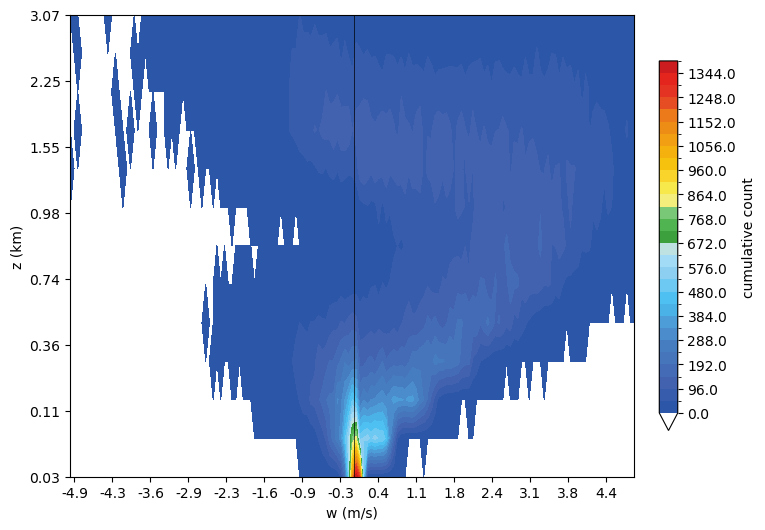

In [73]:
#PLOTTING A SINGLE PLOT
#######################################
import matplotlib.gridspec as gridspec
plot_params = {
    'w': {'number_xbins': 100, 'num_contour_levels': 30, 
          'ylim': (0, 3.5), 'xlim': (-5, 5), 'zero_line': True, 'units': '(m/s)','round_deg': 1},
    'qv': {'number_xbins': 10, 'num_contour_levels': 30, 
           'ylim': (0, 15), 'xlim': (0,18), 'zero_line': True, 'units': '(g/kg)','round_deg': 1},
    'qcqi': {'number_xbins': 10, 'num_contour_levels': 30, 
             'ylim': (0,20), 'xlim': (0,2.8), 'zero_line': False, 'units': '(g/kg)','round_deg': 1},
    'th': {'number_xbins': 20, 'num_contour_levels': 30, 
           'ylim': (0,7), 'xlim': (300,315), 'zero_line': False, 'units': '(K)','round_deg': 1},
    'th_e': {'number_xbins': 50, 'num_contour_levels': 30, 
             'ylim': (0, 15), 'xlim': (325,360), 'zero_line': False, 'units': '(K)','round_deg': 1},
    'buoyancy': {'number_xbins': 30, 'num_contour_levels': 30, 
                 'ylim': (0,15), 'xlim': (-0.2,0.3), 'zero_line': True, 'units': r'$(m/s^2)$','round_deg': 2},
    'HMC': {'number_xbins': 10, 'num_contour_levels': 30, 
            'ylim': (0, 20), 'xlim': None, 'zero_line': True, 'units': '(g/kg/s)','round_deg': 2}
}
def remove_high_counts(var_name, type, bin_array):
    # Define the thresholds for each variable and type
    thresholds = {
        ('HMC', 'DEEP'): 15,
        ('qv', 'DEEP'): 10,
        ('qcqi', 'ALL'): 80,
        ('qcqi', 'SHALLOW'): 40, 
        ('qcqi', 'DEEP'): 5,
        ('HMC', 'ALL'): 160,
    }

    # Check if the (var_name, type) combination is in the thresholds dictionary
    if (var_name, type) in thresholds:
        # Get the threshold value and apply it to the bin_array
        threshold_value = thresholds[(var_name, type)]
        bin_array[bin_array > threshold_value] = 0

    return bin_array


#GETTING VARIABLE
type='ALL'
var_name='w'
bin_array = bin_arrays[type+'_profile_array_'+var_name].copy()
bin_array = remove_high_counts(var_name,type,bin_array)

#PLOTTING
# Create figure and axis
# fig, axis = plt.subplots(figsize=(8,6))
fig = plt.figure(figsize=(8,6))  
gs = gridspec.GridSpec(1, 1, figure=fig)
axis = fig.add_subplot(gs[0, 0])

HistogramPlot(axis,var_name, bin_array, add_grid=False, meters=False, **plot_params[var_name])

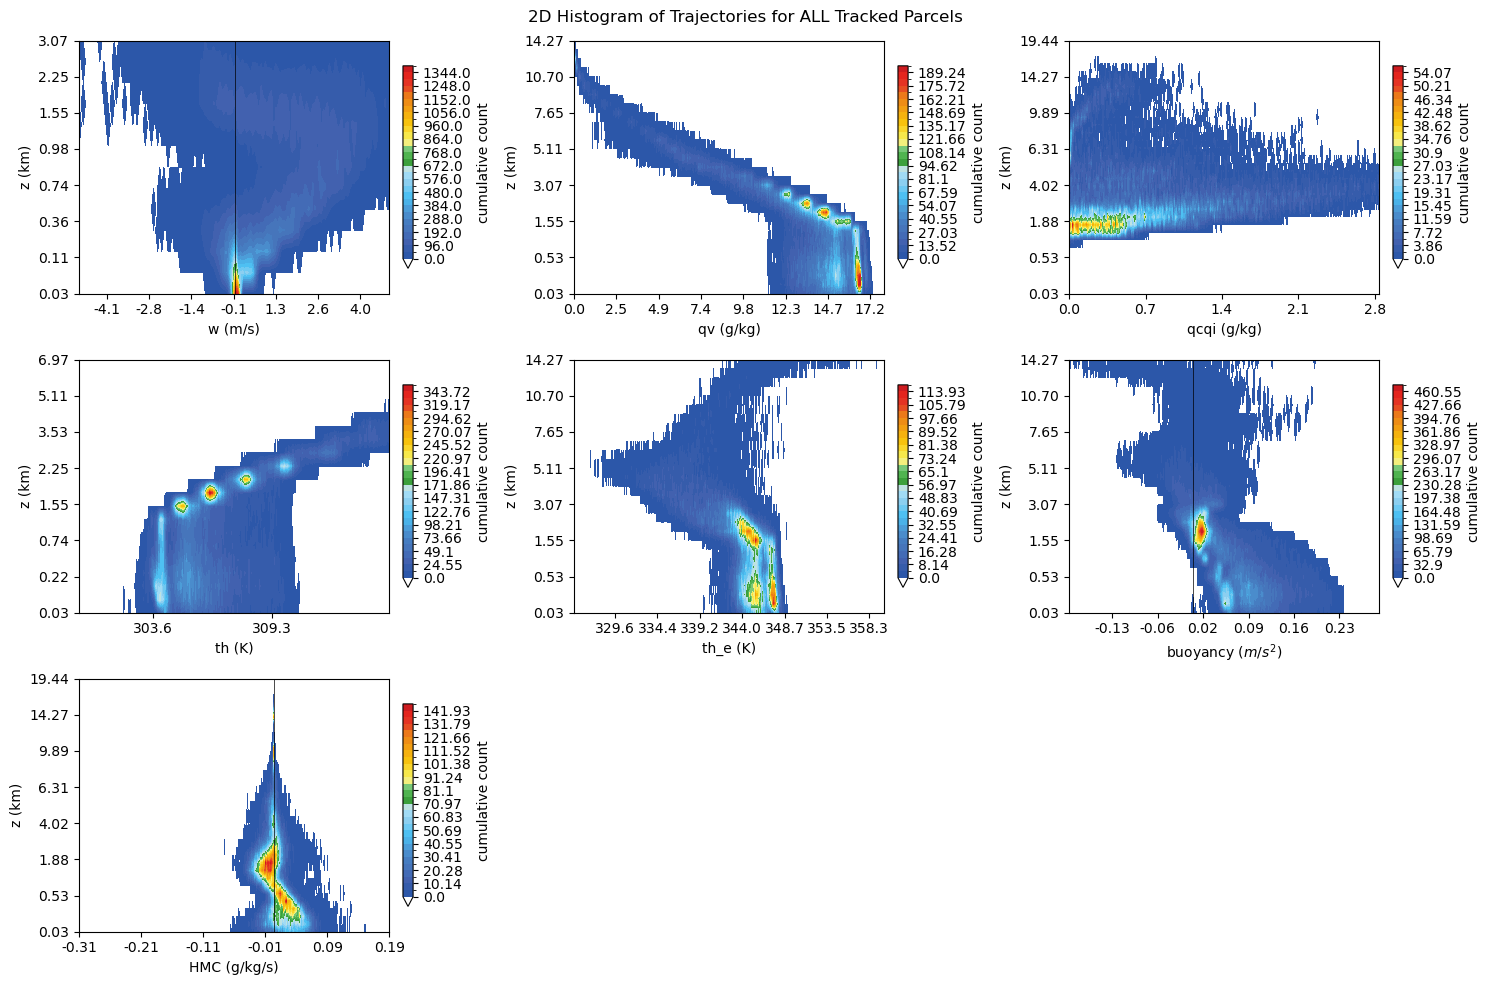

In [74]:
#PLOTTING EVERY PLOT
#######################################
import matplotlib.gridspec as gridspec
plot_params = {
    'w': {'number_xbins': 50, 'num_contour_levels': 30, 
          'ylim': (0, 3.5), 'xlim': (-5, 5), 'zero_line': True, 'units': '(m/s)','round_deg': 1},
    'qv': {'number_xbins': 10, 'num_contour_levels': 30, 
           'ylim': (0, 15), 'xlim': (0,18), 'zero_line': True, 'units': '(g/kg)','round_deg': 1},
    'qcqi': {'number_xbins': 10, 'num_contour_levels': 30, 
             'ylim': (0,20), 'xlim': (0,2.8), 'zero_line': False, 'units': '(g/kg)','round_deg': 1},
    'th': {'number_xbins': 30, 'num_contour_levels': 30, 
           'ylim': (0,7), 'xlim': (300,315), 'zero_line': False, 'units': '(K)','round_deg': 1},
    'th_e': {'number_xbins': 30, 'num_contour_levels': 30, 
             'ylim': (0, 15), 'xlim': (325,360), 'zero_line': False, 'units': '(K)','round_deg': 1},
    'buoyancy': {'number_xbins': 20, 'num_contour_levels': 30, 
                 'ylim': (0,15), 'xlim': (-0.2,0.3), 'zero_line': True, 'units': r'$(m/s^2)$','round_deg': 2},
    'HMC': {'number_xbins': 6, 'num_contour_levels': 30, 
            'ylim': (0, 20), 'xlim': None, 'zero_line': True, 'units': '(g/kg/s)','round_deg': 2}
}
def remove_high_counts(var_name, type, bin_array):
    # Define the thresholds for each variable and type
    thresholds = {
        ('HMC', 'DEEP'): 15,
        ('qv', 'DEEP'): 10,
        ('qcqi', 'ALL'): 80,
        ('qcqi', 'SHALLOW'): 40, 
        ('qcqi', 'DEEP'): 5,
        ('HMC', 'ALL'): 160,
    }

    # Check if the (var_name, type) combination is in the thresholds dictionary
    if (var_name, type) in thresholds:
        # Get the threshold value and apply it to the bin_array
        threshold_value = thresholds[(var_name, type)]
        bin_array[bin_array > threshold_value] = 0

    return bin_array

#####################################
type='ALL'
# type='SHALLOW'
# type='DEEP'

# Create a figure and gridspec layout
fig = plt.figure(figsize=(15, 10))  # Adjust the figure size as needed
gs = gridspec.GridSpec(3, 3, figure=fig)  # Create a gridspec for the number of variables
# Loop through each var_name and plot in the corresponding grid
for idx, (var_name, params) in enumerate(plot_params.items()):
    # Get bin_array for the current variable
    bin_array = bin_arrays[type + '_profile_array_' + var_name].copy()
    bin_array = remove_high_counts(var_name, type, bin_array)

    # Set up subplot in gridspec layout (subplot in a grid, not just a simple axis)
    row = idx // 3  # Calculate row index (integer division by 3)
    col = idx % 3   # Calculate column index (modulo 3)
    axis = fig.add_subplot(gs[row, col])

    # Call the HistogramPlot function with the correct axis
    HistogramPlot(axis, var_name, bin_array, add_grid=False, meters=False, **plot_params[var_name])

#ADD TITLE
fig.suptitle(f"2D Histogram of Trajectories for {type} Tracked Parcels")
# Adjust the layout to avoid overlap
plt.tight_layout()


In [ ]:
#FUTURE COULD ALSO INCREASE NUMBER OF BINS (not neccessary)

In [75]:
#FUTURE COULD ALSO BE DONE FOR NON_CL,SBZ,NON_SBZ, and COLDPOOL ***

In [76]:
# # #TESTING IMSHOW PLOT (OLD)

# import matplotlib.colors as mcolors
# from matplotlib.colors import ListedColormap

# # Prepare data
# bin_array = ALL_profile_array_w.copy()
# bin_array[bin_array == 0] = -1  # Replace 0 values

# #Normalize 
# # bin_array/=np.max(bin_array)

# # Define the colormap
# colors = histogram2d_colors()
# custom_cmap = mcolors.ListedColormap(colors)
# custom_cmap.set_under("white")

# # Create a figure and axis
# fig, axis = plt.subplots(figsize=(8, 6))

# # Plotting without normalization
# im = axis.imshow(bin_array, cmap=custom_cmap, aspect="auto")

# # Flip the y-axis
# axis.invert_yaxis()

# # Add a colorbar with actual raw values
# cbar = plt.colorbar(im, ax=axis, orientation='vertical', fraction=0.05, pad=0.04, shrink=0.8, label='cumulative count', extend="min")

# # Set colorbar ticks based on raw data range
# num_colors = len(colors)
# cbar_ticks = np.linspace(np.min(bin_array[bin_array > 0]), np.max(bin_array), num_colors + 1)  # Avoid -1 values
# cbar.set_ticks(cbar_ticks)
# cbar.set_ticklabels(np.round(cbar_ticks, 2))


# # #Limit the X and Y Range
# # axis.set_ylim((0,10))
# # # axis.set_xlim((400,700))
# # axis.set_xlim((450,550))
# # # axis.set_xlim((490,510))


# # # Add a grid
# # # axis.xaxis.set_major_locator(plt.MultipleLocator(1))  # Show grid for every tick
# # axis.grid(visible=True, axis='x', color='black', linestyle='--', linewidth=0.5)
# # axis.grid(visible=True, axis='y', color='black', linestyle='--', linewidth=0.5)
# # axis.invert_yaxis()